In [2]:
import pandas as pd 

In [38]:
df = pd.read_csv('betting_data.csv')

df = df.drop(columns = ['major_pro_franchises'])
df.head()

,state,state_abv,census_reg,is_legal,online_legal,year_retail_legalized,year_online_legalized,years_since_retail,years_since_online,neighbor_legal_count,...,pct_college_enrolled,college_prop_bets,median_house_income,unemployment_rate,lottery_revenue_per_capita,governor_party,legislature_control,has_tribal_gaming,num_liscenced_operators,tax_rate
0,Alabama,AL,south,0,0,NaN,NaN,0,0,2,...,0.06,0,108210,3.1,0,r,r,1,0,0.0
1,Alaska,AK,west,0,0,NaN,NaN,0,0,0,...,0.03,0,99858,4.6,0,r,r,1,0,0.0
2,Arizona,AZ,west,1,1,2021.0,2021.0,5,5,3,...,0.09,0,99781,3.6,214,d,r,1,14,0.1
3,Arkansas,AR,south,1,1,2019.0,2022.0,7,4,1,...,0.05,1,98678,3.4,186,r,r,1,3,0.2
4,California,CA,west,0,0,NaN,NaN,0,0,3,...,0.07,0,96838,5.3,236,d,d,1,0,0.0


In [39]:
legalized = df[df['online_legal'] == 1]   # 34 states, for market size model
holdouts  = df[df['online_legal'] == 0]   # 17 states, for legalization model

<Axes: >

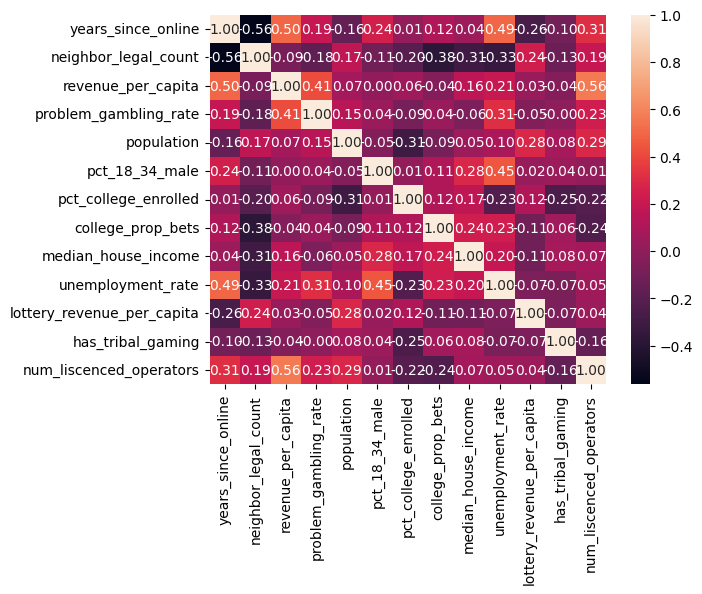

In [58]:
import seaborn as sns

predictor_cols = ['years_since_online','neighbor_legal_count','revenue_per_capita','problem_gambling_rate','population','pct_18_34_male','pct_college_enrolled','college_prop_bets','median_house_income','unemployment_rate','lottery_revenue_per_capita','has_tribal_gaming','num_liscenced_operators']
corr = legalized[predictor_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f')

In [59]:
import numpy as np

# log-transform right-skewed targets and predictors
df['log_revenue_per_capita'] = np.log1p(df['revenue_per_capita'])
df['log_population'] = np.log(df['population'])
df['log_lottery_revenue_pc'] = np.log1p(df['lottery_revenue_per_capita'])

In [67]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_cols = ['years_since_online','neighbor_legal_count','population','pct_18_34_male','pct_college_enrolled','median_house_income','unemployment_rate','lottery_revenue_per_capita','num_liscenced_operators']

legalized[scaled_cols] = scaler.fit_transform(legalized[scaled_cols])
legalized.head()

/var/folders/sw/z1p4fl791_vbf9w_k5_dmrr40000gn/T/ipykernel_8176/3388038164.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  legalized[scaled_cols] = scaler.fit_transform(legalized[scaled_cols])


,state,state_abv,census_reg,is_legal,online_legal,year_retail_legalized,year_online_legalized,years_since_retail,years_since_online,neighbor_legal_count,...,pct_college_enrolled,college_prop_bets,median_house_income,unemployment_rate,lottery_revenue_per_capita,governor_party,legislature_control,has_tribal_gaming,num_liscenced_operators,tax_rate
2,Arizona,AZ,west,1,1,2021.0,2021.0,-0.163707,-0.184947,0.642809,...,1.236690,0,1.848318,-0.093192,-0.528858,d,r,1,1.305344,0.1000
3,Arkansas,AR,south,1,1,2019.0,2022.0,-0.002373,-0.554840,-0.477986,...,-0.533729,1,1.759610,-0.346675,-0.688538,r,r,1,-0.883888,0.2000
5,Colorado,CO,west,1,1,2020.0,2019.0,-0.083040,0.554840,-0.477986,...,-0.091125,0,1.505709,0.033549,-0.956574,d,d,1,1.106323,0.1000
6,Connecticut,CT,northeast,1,1,2021.0,2021.0,-0.163707,-0.184947,-0.477986,...,-0.533729,1,1.489705,0.920738,0.737181,d,d,1,-0.883888,0.1375
7,DC,DC,south,1,1,2019.0,2019.0,-0.002373,0.554840,-1.038383,...,1.236690,1,1.432040,0.287032,-1.749273,r,r,0,-0.684867,0.3000


In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import roc_auc_score

X = df[predictor_cols]
y = df['online_legal']

loo = LeaveOneOut()
model = LogisticRegression(penalty='l2', C=1.0)  # L2 regularization — critical with n=51

In [62]:
import sys
!{sys.executable} -m pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable


In [76]:
df.columns

Index(['state', 'state_abv', 'census_reg', 'is_legal', 'online_legal',
       'year_retail_legalized', 'year_online_legalized', 'years_since_retail',
       'years_since_online', 'neighbor_legal_count', 'neighbor_legal_pct',
       'current_annual_revenue', 'revenue_per_capita', 'problem_gambling_rate',
       'population', 'pct_18_34_male', 'pct_college_enrolled',
       'college_prop_bets', 'median_house_income', 'unemployment_rate',
       'lottery_revenue_per_capita', 'governor_party', 'legislature_control',
       'has_tribal_gaming', 'num_liscenced_operators', 'tax_rate',
       'log_revenue_per_capita', 'log_population', 'log_lottery_revenue_pc'],
      dtype='object')

In [ ]:
scaled_predictor_cols = [
    'neighbor_legal_pct',
    'population',
    'pct_18_34_male',
    'pct_college_enrolled',
    'median_house_income',
    'unemployment_rate',
    'lottery_revenue_per_capita'
]

X = df[scaled_predictor_cols]
y = df['online_legal']

loo = LeaveOneOut()
model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)

loo_probs = cross_val_predict(
    model, X, y,
    cv=loo,
    method='predict_proba'
)[:, 1]  # column 1 is probability of class 1 (has_online_legal = True)

# attach probabilities back to states
results = pd.DataFrame({
    'state': df['state'],
    'online_legal': y,
    'legalization_probability': loo_probs.round(3)
})

# show holdout states ranked by probability
holdout_rankings = (results[results['online_legal'] == 0]
                    .sort_values('legalization_probability', ascending=False))

print(holdout_rankings)

# overall model performance
auc = roc_auc_score(y, loo_probs)
print(f"\nLOO AUC: {auc:.3f}")

             state  online_legal  legalization_probability
10         Georgia             0                     0.950
40  South Carolina             0                     0.942
41    South Dakota             0                     0.852
24     Mississippi             0                     0.718
12           Idaho             0                     0.703
43           Texas             0                     0.674
27        Nebraska             0                     0.580
1           Alaska             0                     0.576
36        Oklahoma             0                     0.570
26         Montana             0                     0.534
31      New Mexico             0                     0.510
44            Utah             0                     0.358
11          Hawaii             0                     0.355
4       California             0                     0.300
34    North Dakota             0                     0.284
0          Alabama             0                     0.2

In [80]:
feature_importance = pd.DataFrame({
    'feature': scaled_predictor_cols,
    'coefficient': model.fit(X, y).coef_[0]
}).sort_values('coefficient', ascending=False)

print(feature_importance)

                      feature   coefficient
6  lottery_revenue_per_capita  7.734017e-03
5           unemployment_rate  2.688017e-05
2              pct_18_34_male  3.631683e-07
3        pct_college_enrolled  2.202955e-07
1                  population -6.146581e-08
0          neighbor_legal_pct -5.362827e-06
4         median_house_income -7.174906e-06
